In [2]:
import os
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt



In [27]:
def plot_probabilities_2d(X, y, model):
    #Генерируем координатную сетку из всех возможных значений для признаков
    #Glucose изменяется от x1_min = 44 до x2_max = 199, 
    #BMI — от x2_min = 18.2 до x2_max = 67.1
    #Результат работы функции — два массива xx1 и xx2, которые образуют координатную сетку
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    #Вытягиваем каждый из массивов в вектор-столбец — reshape(-1, 1)
    #Объединяем два столбца в таблицу с помощью hstack
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    #Предсказываем вероятность для всех точек на координатной сетке
    #Нам нужна только вероятность класса 1
    probs = model.predict_proba(X_net)[:, 1]
    #Переводим столбец из вероятностей в размер координатной сетки
    probs = probs.reshape(xx1.shape)
    #Создаём фигуру и координатную плоскость
    fig, ax = plt.subplots(figsize = (10, 5))
    #Рисуем тепловую карту вероятностей
    contour = ax.contourf(xx1, xx2, probs, 100, cmap='bwr')
    #Рисуем разделяющую плоскость (линию, где вероятность равна 0.5)
    bound = ax.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    #Добавляем цветовую панель 
    colorbar = fig.colorbar(contour)
    #Накладываем поверх тепловой карты диаграмму рассеяния
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette='seismic', ax=ax)
    #Даём графику название
    ax.set_title('Scatter Plot with Decision Boundary');
    #Смещаем легенду в верхний левый угол вне графика
    ax.legend(bbox_to_anchor=(-0.05, 1))

# Импорт данных

,Unnamed: 0,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,...,contrast_6,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,duration,filename,label
0,0,-305.57578,98.69117,91.518230,64.501396,-8.724127,35.467377,7.637456,37.009800,-9.634664,...,27.074734,0.075360,0.048465,-0.009360,0.015261,0.010162,0.015641,2.665805,file1.wav,0
1,1,-274.76038,69.54157,120.229614,42.357440,-14.591383,27.415894,61.321335,29.847486,-11.726446,...,54.869202,0.009631,-0.016616,-0.016197,-0.000622,-0.004349,-0.005843,4.875011,file10.wav,0
2,2,-316.97860,99.30693,120.701470,62.973370,18.388845,31.745300,60.508990,35.698803,-3.781815,...,60.676906,0.020359,0.035678,-0.023923,0.022404,0.015635,0.011816,3.815102,file100.wav,0
3,3,-309.61940,105.73170,89.720440,83.421850,3.568671,46.698280,8.826833,34.290250,-21.344273,...,27.397443,-0.011907,-0.003595,0.003600,0.000963,0.012534,0.004236,9.713061,file1000.wav,0
4,4,-291.03210,71.63723,88.693660,92.446915,-8.028616,52.509770,2.189749,36.795242,-13.003433,...,27.370921,0.017905,0.005795,0.032928,0.016310,-0.002953,0.002103,4.430522,file10000.wav,0


<Axes: xlabel='label', ylabel='count'>

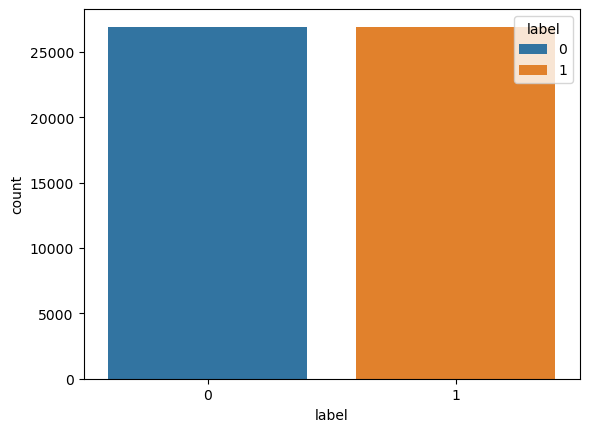

In [47]:
training_df = pd.read_csv('training.csv')
testing_df = pd.read_csv('testing.csv')
validation_df = pd.read_csv('validation.csv')
training_df['label'] = training_df['label'].astype('category')
testing_df['label'] = testing_df['label'].astype('category')
# validation_df['label'] = training_df['label'].astype('category')


display(training_df.head())
training_df['label'].value_counts()
sns.countplot(data=training_df, x='label', hue='label')

In [48]:
# векторы признаков
X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
# векторы ответов
y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']
X_valid.head()

,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,contrast_3,contrast_4,contrast_5,contrast_6,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5
0,-311.51804,108.219300,82.452065,54.362095,-0.866406,41.808370,21.114666,27.142424,-14.718886,23.476416,...,19.329285,19.949279,22.584370,27.199025,0.022784,0.013428,-0.015054,0.000862,0.001114,-0.000384
1,-298.88530,86.319350,97.215020,74.828125,2.661584,47.882668,3.313045,35.063866,-12.544292,23.904390,...,17.215255,20.771091,21.301038,26.928983,0.017945,-0.006906,0.027744,0.038287,0.004151,0.003610
2,-368.31213,135.093490,110.413940,38.224890,-4.557162,40.481030,44.569620,36.240547,10.459233,17.943512,...,13.942254,15.400996,16.913952,56.555454,-0.006876,0.006312,-0.006268,0.029629,0.004202,0.005358
3,-310.99747,84.175080,78.490330,74.415250,-8.453429,40.919926,26.348724,42.842438,-5.376661,17.668960,...,17.327210,20.631316,22.118647,28.462182,-0.006960,-0.008168,0.009596,-0.017637,0.011438,0.013301
4,-278.65915,91.293106,105.651610,52.242825,4.457033,32.129837,17.706459,35.052254,0.802172,26.204030,...,16.714447,19.405557,19.181224,45.228390,-0.009180,-0.017285,-0.019807,-0.041120,0.013253,-0.001772


<Axes: >

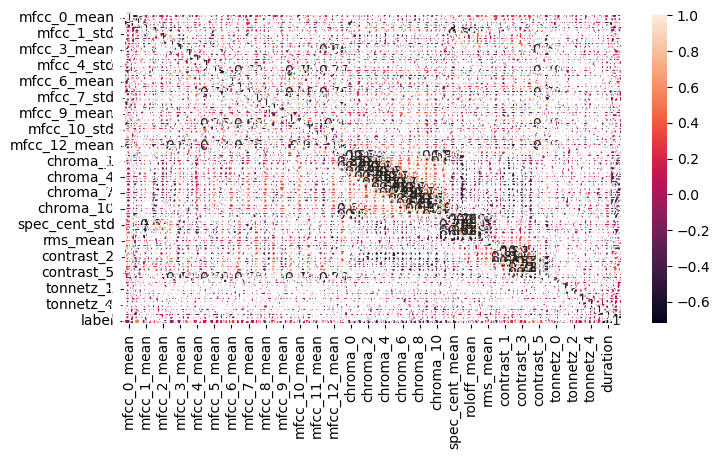

In [31]:
# check_corr = training_df.drop(['Unnamed: 0', 'filename'])
fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(training_df.drop(['Unnamed: 0', 'filename'], axis=1).corr(), annot=True)

## Random Forest

In [56]:
from sklearn import ensemble, metrics
rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=60, # число деревьев
    criterion='entropy', # критерий эффективности
    max_depth=20, # глубина дерева
    max_features='sqrt', # максимальное число признаков
    random_state=42 # генерация случайны чисел
)


# обучаем модель
rf_clf_full.fit(X_train, y_train)

y_pred_test = rf_clf_full.predict(X_test)
y_pred_valid = rf_clf_full.predict(X_valid)

print('Test metrics:\n', metrics.classification_report(y_test, y_pred_test))
print('Validation metrics:\n', metrics.classification_report(y_valid, y_pred_valid))

Test metrics:
               precision    recall  f1-score   support

           0       0.76      1.00      0.86      2264
           1       1.00      0.69      0.82      2370

    accuracy                           0.84      4634
   macro avg       0.88      0.85      0.84      4634
weighted avg       0.88      0.84      0.84      4634

Validation metrics:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5400
           1       1.00      1.00      1.00      5398

    accuracy                           1.00     10798
   macro avg       1.00      1.00      1.00     10798
weighted avg       1.00      1.00      1.00     10798



## XGBM

In [54]:
import xgboost as xgb

xgb_train = xgb.DMatrix(X_train, y_train)
xgb_test = xgb.DMatrix(X_test, y_test)
xgb_valid = xgb.DMatrix(X_valid, y_valid)

xgb_model = xgb.train(
    params={
        'objective': 'binary:logistic',
        'max_depth': 3,
        'learning_rate': 0.1,
    },
    dtrain=xgb_train,
    num_boost_round=50
)

y_xgb_test_pred = xgb_model.predict(xgb_test) # предсказание на тестовом наборе ответов
y_xgb_test_pred = (y_xgb_test_pred > 0.75).astype(int)

y_xgb_valid_pred = xgb_model.predict(xgb_valid) # предсказание на валидационном наборе ответов
y_xgb_valid_pred = (y_xgb_valid_pred > 0.75).astype(int)


print('Testing metrics score:\n', metrics.classification_report(y_test, y_xgb_test_pred))
print('Validation metrics score:\n', metrics.classification_report(y_valid, y_xgb_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90      2264
           1       1.00      0.79      0.88      2370

    accuracy                           0.89      4634
   macro avg       0.91      0.89      0.89      4634
weighted avg       0.91      0.89      0.89      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      5400
           1       1.00      0.96      0.98      5398

    accuracy                           0.98     10798
   macro avg       0.98      0.98      0.98     10798
weighted avg       0.98      0.98      0.98     10798



## KNN

In [51]:
from sklearn import neighbors

knn_model = neighbors.KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

knn_y_test_pred = knn_model.predict(X_test)
knn_y_valid_pred = knn_model.predict(X_valid)
print('Testing metrics score:\n',metrics.classification_report(y_test, knn_y_test_pred))
print('Validation metrics score:\n',metrics.classification_report(y_valid, knn_y_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2264
           1       0.97      0.88      0.93      2370

    accuracy                           0.93      4634
   macro avg       0.93      0.93      0.93      4634
weighted avg       0.93      0.93      0.93      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      5400
           1       0.95      0.94      0.95      5398

    accuracy                           0.95     10798
   macro avg       0.95      0.95      0.95     10798
weighted avg       0.95      0.95      0.95     10798

